goal : extract dinov3 features from MedSegBench

In [2]:
from src.config import load_config
config = load_config()
from medsegbench import AbdomenUSMSBench
from torchvision import transforms

# Define a custom transform
to_tensor = transforms.Compose([
    transforms.Resize((224, 224)),  # Resizes images to 224x224
    transforms.ToTensor(),  # Converts PIL to tensor [C, H, W] in [0, 1]
    # resizes images to 256x256
])
train_dataset = AbdomenUSMSBench(split='train',
                                root = config["paths"]["medsegbench"],
                                download=False,
                                transform=to_tensor  # This will convert PIL images to tensors
)

In [3]:
from transformers import AutoImageProcessor, AutoModel
from huggingface_hub import login
pretrained_model_name = config["paths"]["ckpts"]["dino_vit"]

#pretrained_model_name = "facebook/dinov3-convnext-large-pretrain-lvd1689m"

processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(
    pretrained_model_name, 
    device_map="auto", 
)



In [4]:
model

DINOv3ViTModel(
  (embeddings): DINOv3ViTEmbeddings(
    (patch_embeddings): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
  )
  (rope_embeddings): DINOv3ViTRopePositionEmbedding()
  (layer): ModuleList(
    (0-23): 24 x DINOv3ViTLayer(
      (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (attention): DINOv3ViTAttention(
        (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
      )
      (layer_scale1): DINOv3ViTLayerScale()
      (drop_path): Identity()
      (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (mlp): DINOv3ViTMLP(
        (up_proj): Linear(in_features=1024, out_features=4096, bias=True)
        (down_proj): Linear(in_features=4096, out_features=1024, bias=True)
        (act_fn): GELUA

In [6]:
attention_layer = model.layer[0].attention
print(attention_layer)

DINOv3ViTAttention(
  (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
  (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
  (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
  (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
)


In [7]:
import inspect
from transformers.models.dinov3_vit.modeling_dinov3_vit import DINOv3ViTAttention
print(inspect.getsource(DINOv3ViTAttention))

class DINOv3ViTAttention(nn.Module):
    """
    Multi-headed attention compatible with ALL_ATTENTION_FUNCTIONS.
    """

    def __init__(self, config: DINOv3ViTConfig):
        super().__init__()
        self.config = config
        self.embed_dim = config.hidden_size
        self.num_heads = config.num_attention_heads
        self.head_dim = self.embed_dim // self.num_heads
        self.is_causal = False

        self.scaling = self.head_dim**-0.5
        self.is_causal = False

        self.dropout = config.attention_dropout
        self.k_proj = nn.Linear(self.embed_dim, self.embed_dim, bias=config.key_bias)
        self.v_proj = nn.Linear(self.embed_dim, self.embed_dim, bias=config.value_bias)

        self.q_proj = nn.Linear(self.embed_dim, self.embed_dim, bias=config.query_bias)
        self.o_proj = nn.Linear(self.embed_dim, self.embed_dim, bias=config.proj_bias)

    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor]

In [10]:
# ===== DINOv3ViT Model Structure Analysis =====

def analyze_dinov3_model(model):
    """Extract and summarize all architectural details from DINOv3ViT model."""
    
    config = model.config
    summary = {}
    
    # === 1. Basic Architecture Info ===
    summary["architecture"] = {
        "model_type": config.model_type,
        "hidden_size": config.hidden_size,
        "num_hidden_layers": config.num_hidden_layers,
        "num_attention_heads": config.num_attention_heads,
        "head_dim": config.hidden_size // config.num_attention_heads,
        "intermediate_size": config.intermediate_size,
        "hidden_act": config.hidden_act,
        "attention_implementation": config._attn_implementation,
    }
    
    # === 2. Patch Embedding Info ===
    summary["patch_embedding"] = {
        "image_size": config.image_size,
        "patch_size": config.patch_size,
        "num_channels": config.num_channels,
        "num_patches": (config.image_size // config.patch_size) ** 2,
        "grid_size": config.image_size // config.patch_size,
    }
    
    # === 3. Special Tokens ===
    summary["special_tokens"] = {
        "use_cls_token": getattr(config, "use_cls_token", True),
        "num_register_tokens": getattr(config, "num_register_tokens", 0),
    }
    
    # === 4. Positional Embedding ===
    summary["positional_embedding"] = {
        "type": "RoPE (Rotary Position Embedding)",
        "rope_theta": getattr(config, "rope_theta", None),
        "interpolate_pos_encoding": getattr(config, "interpolate_pos_encoding", None),
    }
    
    # === 5. Attention Configuration ===
    summary["attention"] = {
        "num_heads": config.num_attention_heads,
        "head_dim": config.hidden_size // config.num_attention_heads,
        "attention_dropout": config.attention_dropout,
        "query_bias": getattr(config, "query_bias", True),
        "key_bias": getattr(config, "key_bias", True),
        "value_bias": getattr(config, "value_bias", True),
        "proj_bias": getattr(config, "proj_bias", True),
    }
    
    # === 6. MLP Configuration ===
    summary["mlp"] = {
        "intermediate_size": config.intermediate_size,
        "hidden_act": config.hidden_act,
        "mlp_ratio": config.intermediate_size / config.hidden_size,
    }
    
    # === 7. Normalization & Regularization ===
    summary["normalization"] = {
        "layer_norm_eps": config.layer_norm_eps,
        "hidden_dropout_prob": getattr(config, "hidden_dropout_prob", 0.0),
        "use_layer_scale": getattr(config, "layerscale_value", None) is not None,
        "layerscale_value": getattr(config, "layerscale_value", None),
    }
    
    # === 8. Parameter Count ===
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    summary["parameters"] = {
        "total": f"{total_params:,}",
        "trainable": f"{trainable_params:,}",
        "total_millions": f"{total_params / 1e6:.1f}M",
    }
    
    # === 9. Layer-wise breakdown ===
    embeddings_params = sum(p.numel() for p in model.embeddings.parameters())
    layer_params = sum(p.numel() for p in model.layer.parameters())
    
    # Per-layer breakdown for first encoder layer
    first_layer = model.layer[0]
    attn_params = sum(p.numel() for p in first_layer.attention.parameters())
    mlp_params = sum(p.numel() for p in first_layer.mlp.parameters())
    norm_params = sum(p.numel() for p in first_layer.norm1.parameters()) + sum(p.numel() for p in first_layer.norm2.parameters())
    
    summary["parameter_breakdown"] = {
        "embeddings": f"{embeddings_params:,}",
        "all_layers": f"{layer_params:,}",
        "per_layer_attention": f"{attn_params:,}",
        "per_layer_mlp": f"{mlp_params:,}",
        "per_layer_norms": f"{norm_params:,}",
    }
    
    return summary

# Run analysis
summary = analyze_dinov3_model(model)

# Pretty print
print("=" * 60)
print("DINOv3ViT MODEL ARCHITECTURE SUMMARY")
print("=" * 60)

for section, values in summary.items():
    print(f"\n### {section.upper().replace('_', ' ')} ###")
    for key, value in values.items():
        print(f"  {key}: {value}")

DINOv3ViT MODEL ARCHITECTURE SUMMARY

### ARCHITECTURE ###
  model_type: dinov3_vit
  hidden_size: 1024
  num_hidden_layers: 24
  num_attention_heads: 16
  head_dim: 64
  intermediate_size: 4096
  hidden_act: gelu
  attention_implementation: sdpa

### PATCH EMBEDDING ###
  image_size: 224
  patch_size: 16
  num_channels: 3
  num_patches: 196
  grid_size: 14

### SPECIAL TOKENS ###
  use_cls_token: True
  num_register_tokens: 4

### POSITIONAL EMBEDDING ###
  type: RoPE (Rotary Position Embedding)
  rope_theta: 100.0
  interpolate_pos_encoding: None

### ATTENTION ###
  num_heads: 16
  head_dim: 64
  attention_dropout: 0.0
  query_bias: True
  key_bias: False
  value_bias: True
  proj_bias: True

### MLP ###
  intermediate_size: 4096
  hidden_act: gelu
  mlp_ratio: 4.0

### NORMALIZATION ###
  layer_norm_eps: 1e-05
  hidden_dropout_prob: 0.0
  use_layer_scale: True
  layerscale_value: 1.0

### PARAMETERS ###
  total: 303,129,600
  trainable: 303,129,600
  total_millions: 303.1M

### PAR

In [11]:
# ===== Detailed Component Inspection =====

print("=" * 60)
print("DETAILED COMPONENT STRUCTURE")
print("=" * 60)

# 1. Embeddings
print("\n### EMBEDDINGS MODULE ###")
print(model.embeddings)

# 2. RoPE Embeddings
print("\n### ROPE POSITION EMBEDDINGS ###")
print(model.rope_embeddings)
print(f"  RoPE module type: {type(model.rope_embeddings).__name__}")

# 3. First Transformer Layer
print("\n### TRANSFORMER LAYER STRUCTURE (Layer 0) ###")
layer0 = model.layer[0]
print(layer0)

# 4. Attention weights shapes
print("\n### ATTENTION PROJECTION SHAPES ###")
attn = layer0.attention
print(f"  Q projection: {attn.q_proj.weight.shape} (bias={attn.q_proj.bias is not None})")
print(f"  K projection: {attn.k_proj.weight.shape} (bias={attn.k_proj.bias is not None})")
print(f"  V projection: {attn.v_proj.weight.shape} (bias={attn.v_proj.bias is not None})")
print(f"  O projection: {attn.o_proj.weight.shape} (bias={attn.o_proj.bias is not None})")

# 5. MLP structure
print("\n### MLP STRUCTURE ###")
mlp = layer0.mlp
for name, module in mlp.named_children():
    if hasattr(module, 'weight'):
        print(f"  {name}: {module.weight.shape}")
    else:
        print(f"  {name}: {type(module).__name__}")

# 6. Layer Scale values
print("\n### LAYER SCALE VALUES ###")
print(f"  layer_scale1: {layer0.layer_scale1.lambda1.shape}, init_value check: {layer0.layer_scale1.lambda1[0].item():.4f}")
print(f"  layer_scale2: {layer0.layer_scale2.lambda1.shape}, init_value check: {layer0.layer_scale2.lambda1[0].item():.4f}")

# 7. Final LayerNorm
print("\n### FINAL NORM ###")
print(f"  norm: {model.norm}")

DETAILED COMPONENT STRUCTURE

### EMBEDDINGS MODULE ###
DINOv3ViTEmbeddings(
  (patch_embeddings): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
)

### ROPE POSITION EMBEDDINGS ###
DINOv3ViTRopePositionEmbedding()
  RoPE module type: DINOv3ViTRopePositionEmbedding

### TRANSFORMER LAYER STRUCTURE (Layer 0) ###
DINOv3ViTLayer(
  (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (attention): DINOv3ViTAttention(
    (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
    (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
    (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (layer_scale1): DINOv3ViTLayerScale()
  (drop_path): Identity()
  (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (mlp): DINOv3ViTMLP(
    (up_proj): Linear(in_features=1024, out_features=4096, bias=True)
    (down_proj): Linear(in_features=4096, out_features=1

## DINOv3 ViT-L Architecture Summary

### Overview
- **Model**: DINOv3 Vision Transformer Large (ViT-L/16)
- **Parameters**: 303M total (all trainable)
- **Input**: 224×224 RGB images → 196 patches (14×14 grid)

### Key Architectural Features

#### 1. Patch Embedding
- **Conv2d** projection: 3 → 1024 channels, 16×16 kernel/stride
- No position embedding in embedding layer (handled by RoPE)

#### 2. Special Tokens
- **1 CLS token**: Global image representation
- **4 Register tokens**: Learned tokens for attention sink (from "Vision Transformers Need Registers")
- **Total sequence length**: 1 + 4 + 196 = 201 tokens

#### 3. Positional Encoding: RoPE (Rotary Position Embedding)
- **Type**: 2D Rotary Position Embeddings
- **θ (theta)**: 100.0
- Applied to Q and K in attention (not V)
- Enables **variable resolution inference**

#### 4. Attention Mechanism
- **16 heads**, head dim = 64
- **No key bias** (different from Q, V, O which have bias)
- Scaling: $\frac{1}{\sqrt{d_k}} = \frac{1}{\sqrt{64}} = 0.125$
- Implementation: SDPA (Scaled Dot-Product Attention with Flash/Memory-efficient)

#### 5. MLP (Feed-Forward Network)
- **Expansion ratio**: 4× (1024 → 4096 → 1024)
- **Activation**: GELU
- Two linear projections: `up_proj` and `down_proj`

#### 6. Layer Scale (from CaiT/DeiT-III)
- Learnable per-channel scaling after attention and MLP
- Initialized to 1.0, learned during training
- Helps training stability for deep transformers

#### 7. Transformer Block Order
```
x → LayerNorm → Attention → LayerScale1 → DropPath → (+x residual)
  → LayerNorm → MLP       → LayerScale2 → DropPath → (+x residual)
```

### Output
- **last_hidden_state**: [B, 201, 1024] (all tokens)
- For segmentation: use patch tokens [B, 196, 1024], reshape to [B, 1024, 14, 14]

In [15]:
# First, clear any lingering hooks by reloading the model from state
# This ensures clean state
model_config = model.config
model_state = model.state_dict()

# Reload to clear hooks
from transformers import AutoModel
model = AutoModel.from_pretrained(pretrained_model_name, device_map="auto")
print("Model reloaded with clean state")

Model reloaded with clean state


Computing attention weights (Layer 0)...
Attention shape: torch.Size([16, 201, 201])

CASE 1: HORIZONTALLY ADJACENT
ATTENTION FROM PATCH (7, 7) TO PATCH (7, 8)

Token indices: query=110, key=111
Grid distance: Δrow=0, Δcol=-1
Euclidean: 1.00 patches

### Attention (7, 7) → (7, 8) per head:
  Head  0: 0.06959 █████████████
  Head  1: 0.00376 
  Head  2: 0.00057 
  Head  3: 0.00081 
  Head  4: 0.08650 █████████████████
  Head  5: 0.00391 
  Head  6: 0.00482 
  Head  7: 0.01138 ██
  Head  8: 0.00242 
  Head  9: 0.00537 █
  Head 10: 0.00359 
  Head 11: 0.00006 
  Head 12: 0.00484 
  Head 13: 0.00506 █
  Head 14: 0.00000 
  Head 15: 0.00229 

  Mean: 0.01281  |  Max: 0.08650 (head 4)
  Reverse ((7, 8)→(7, 7)) mean: 0.01207


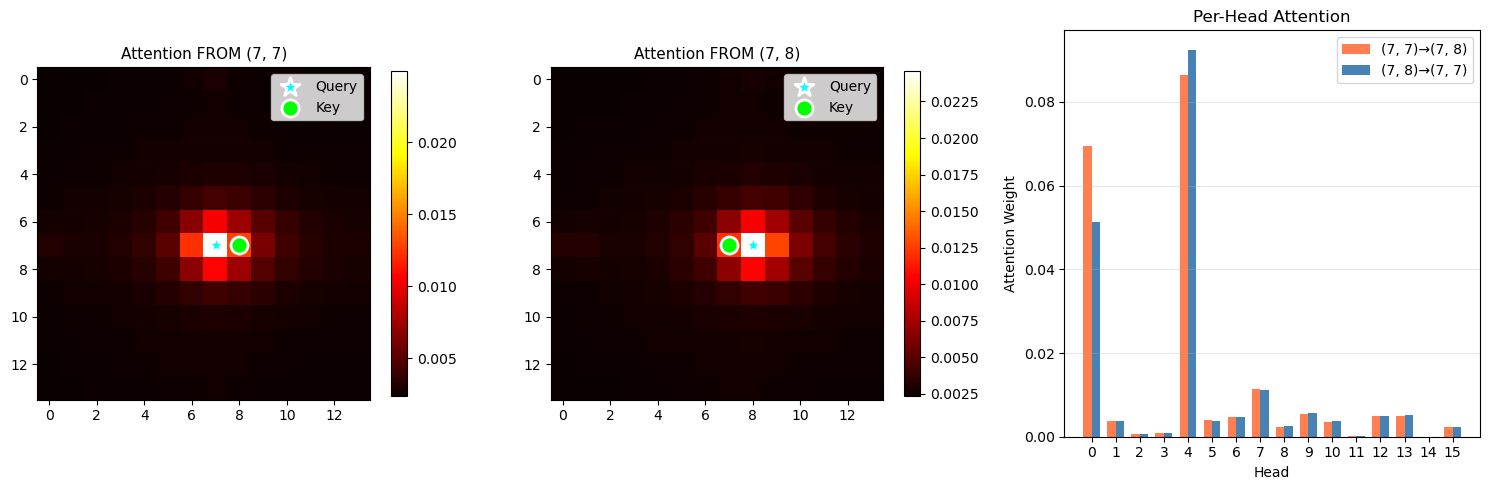


CASE 2: DIAGONAL NEIGHBORS
ATTENTION FROM PATCH (7, 7) TO PATCH (8, 8)

Token indices: query=110, key=125
Grid distance: Δrow=-1, Δcol=-1
Euclidean: 1.41 patches

### Attention (7, 7) → (8, 8) per head:
  Head  0: 0.04612 █████████
  Head  1: 0.00374 
  Head  2: 0.00056 
  Head  3: 0.00080 
  Head  4: 0.02292 ████
  Head  5: 0.00377 
  Head  6: 0.00483 
  Head  7: 0.01087 ██
  Head  8: 0.00246 
  Head  9: 0.00524 █
  Head 10: 0.00390 
  Head 11: 0.00006 
  Head 12: 0.00483 
  Head 13: 0.00501 █
  Head 14: 0.00000 
  Head 15: 0.00228 

  Mean: 0.00734  |  Max: 0.04612 (head 0)
  Reverse ((8, 8)→(7, 7)) mean: 0.00668


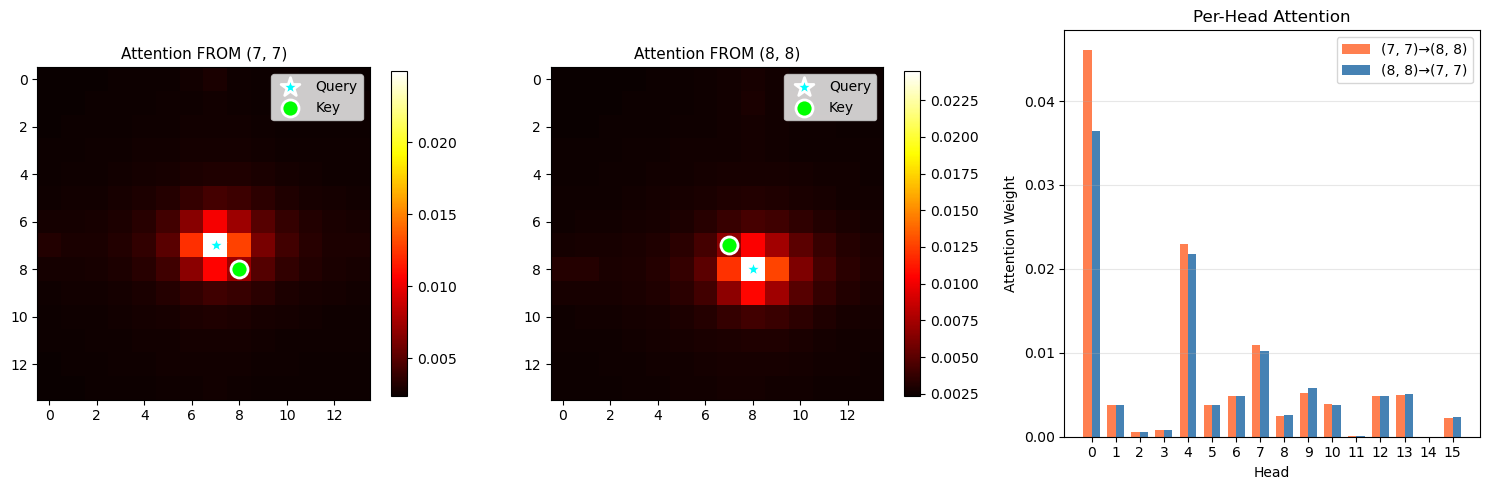


CASE 3: DISTANT PATCHES
ATTENTION FROM PATCH (2, 2) TO PATCH (11, 11)

Token indices: query=35, key=170
Grid distance: Δrow=-9, Δcol=-9
Euclidean: 12.73 patches

### Attention (2, 2) → (11, 11) per head:
  Head  0: 0.00000 
  Head  1: 0.00330 
  Head  2: 0.00044 
  Head  3: 0.00078 
  Head  4: 0.00002 
  Head  5: 0.00305 
  Head  6: 0.00476 
  Head  7: 0.00201 
  Head  8: 0.00246 
  Head  9: 0.00445 
  Head 10: 0.00602 █
  Head 11: 0.00006 
  Head 12: 0.00480 
  Head 13: 0.00455 
  Head 14: 0.00000 
  Head 15: 0.00215 

  Mean: 0.00243  |  Max: 0.00602 (head 10)
  Reverse ((11, 11)→(2, 2)) mean: 0.00239


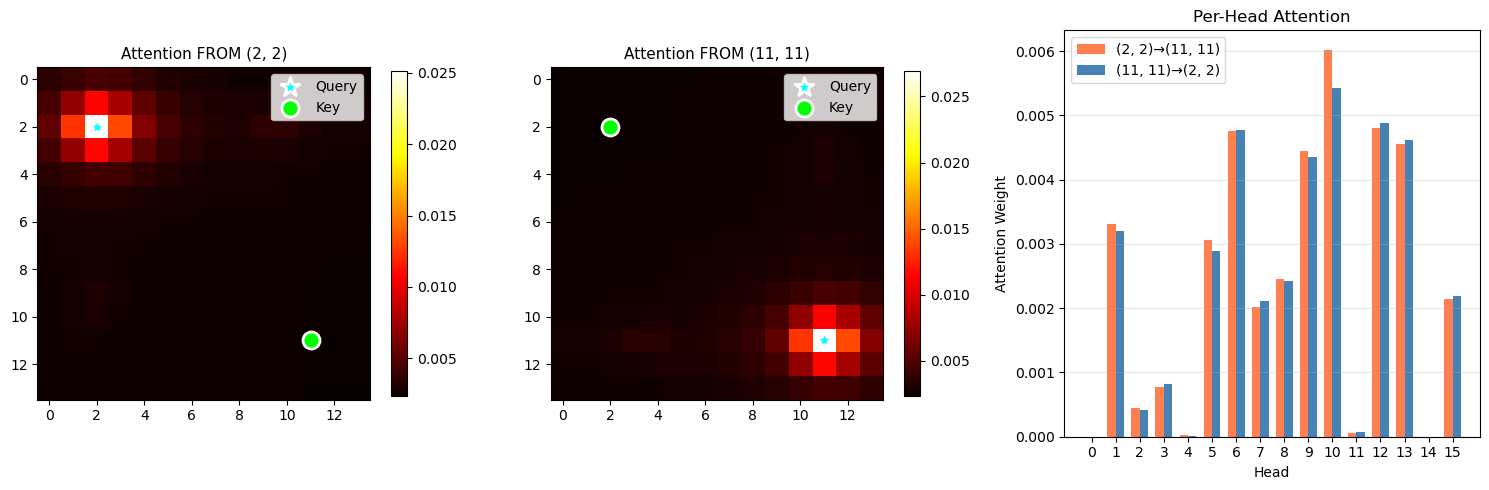

(array([1.3877817e-12, 3.3046245e-03, 4.4055522e-04, 7.7795738e-04,
        2.0676389e-05, 3.0532444e-03, 4.7600232e-03, 2.0126621e-03,
        2.4568790e-03, 4.4472637e-03, 6.0210084e-03, 6.0080063e-05,
        4.8022531e-03, 4.5532701e-03, 2.2458487e-07, 2.1470417e-03],
       dtype=float32),
 array([4.9748243e-13, 3.2049224e-03, 4.1865872e-04, 8.2557206e-04,
        1.4883989e-05, 2.8871486e-03, 4.7654356e-03, 2.1126077e-03,
        2.4206170e-03, 4.3584523e-03, 5.4199351e-03, 6.6997680e-05,
        4.8818979e-03, 4.6111499e-03, 2.7992891e-07, 2.1854253e-03],
       dtype=float32))

In [18]:
# ===== Visualize Attention Between Specific Patch Locations =====
import torch
import matplotlib.pyplot as plt
import numpy as np

def compute_attention_manually(model, image, layer_idx=0):
    """
    Manually compute attention weights by intercepting Q, K.
    Handles the fact that RoPE is only applied to patch tokens, not special tokens.
    """
    device = next(model.parameters()).device
    inputs = processor(images=image, return_tensors="pt").to(device)
    
    captured = {}
    layer = model.layer[layer_idx]
    
    def norm1_hook(module, inp, out):
        captured['norm1_output'] = out.detach().clone()
    
    def rope_hook(module, inp, out):
        captured['cos'] = out[0].detach().clone()
        captured['sin'] = out[1].detach().clone()
    
    h1 = layer.norm1.register_forward_hook(norm1_hook)
    h2 = model.rope_embeddings.register_forward_hook(rope_hook)
    
    try:
        with torch.no_grad():
            outputs = model(**inputs)
    finally:
        h1.remove()
        h2.remove()
    
    # Compute attention manually
    attn_module = layer.attention
    hidden_states = captured['norm1_output']  # [B, 201, 1024]
    
    B, N, _ = hidden_states.shape
    num_special = 5  # CLS + 4 registers
    
    q = attn_module.q_proj(hidden_states)
    k = attn_module.k_proj(hidden_states)
    
    num_heads = attn_module.num_heads
    head_dim = attn_module.head_dim
    
    q = q.view(B, N, num_heads, head_dim).transpose(1, 2)  # [B, H, N, D]
    k = k.view(B, N, num_heads, head_dim).transpose(1, 2)
    
    # Apply RoPE only to patch tokens (positions 5:)
    cos, sin = captured['cos'], captured['sin']  # [1, 1, 196, 64]
    
    def rotate_half(x):
        x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat([-x2, x1], dim=-1)
    
    # Split special tokens and patch tokens
    q_special = q[:, :, :num_special, :]  # [B, H, 5, D]
    q_patches = q[:, :, num_special:, :]   # [B, H, 196, D]
    k_special = k[:, :, :num_special, :]
    k_patches = k[:, :, num_special:, :]
    
    # Apply RoPE to patch tokens
    q_patches_rot = (q_patches * cos) + (rotate_half(q_patches) * sin)
    k_patches_rot = (k_patches * cos) + (rotate_half(k_patches) * sin)
    
    # Concatenate back (special tokens unchanged)
    q_rot = torch.cat([q_special, q_patches_rot], dim=2)
    k_rot = torch.cat([k_special, k_patches_rot], dim=2)
    
    # Attention: Q @ K^T / sqrt(d)
    scale = head_dim ** -0.5
    attn_weights = torch.matmul(q_rot, k_rot.transpose(-2, -1)) * scale
    attn_weights = torch.softmax(attn_weights, dim=-1)
    
    return attn_weights[0].detach().cpu()


def visualize_attention_between_patches(attn_weights, pos1, pos2):
    """Visualize attention between two patch positions."""
    num_heads = attn_weights.shape[0]
    
    num_special = 5
    idx1 = num_special + pos1[0] * 14 + pos1[1]
    idx2 = num_special + pos2[0] * 14 + pos2[1]
    
    print(f"=" * 60)
    print(f"ATTENTION FROM PATCH {pos1} TO PATCH {pos2}")
    print(f"=" * 60)
    print(f"\nToken indices: query={idx1}, key={idx2}")
    print(f"Grid distance: Δrow={pos1[0]-pos2[0]}, Δcol={pos1[1]-pos2[1]}")
    print(f"Euclidean: {np.sqrt((pos1[0]-pos2[0])**2 + (pos1[1]-pos2[1])**2):.2f} patches")
    
    attn_1to2 = attn_weights[:, idx1, idx2].detach().numpy()
    attn_2to1 = attn_weights[:, idx2, idx1].detach().numpy()
    
    print(f"\n### Attention {pos1} → {pos2} per head:")
    for h in range(num_heads):
        bar = "█" * int(attn_1to2[h] * 200)
        print(f"  Head {h:2d}: {attn_1to2[h]:.5f} {bar}")
    print(f"\n  Mean: {attn_1to2.mean():.5f}  |  Max: {attn_1to2.max():.5f} (head {attn_1to2.argmax()})")
    print(f"  Reverse ({pos2}→{pos1}) mean: {attn_2to1.mean():.5f}")
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Attention FROM pos1
    attn_map1 = attn_weights[:, idx1, num_special:].mean(0).detach().numpy().reshape(14, 14)
    im1 = axes[0].imshow(attn_map1, cmap='hot')
    axes[0].scatter([pos1[1]], [pos1[0]], c='cyan', s=200, marker='*', edgecolors='white', linewidths=2, label='Query')
    axes[0].scatter([pos2[1]], [pos2[0]], c='lime', s=150, marker='o', edgecolors='white', linewidths=2, label='Key')
    axes[0].set_title(f'Attention FROM {pos1}', fontsize=11)
    axes[0].legend(loc='upper right')
    plt.colorbar(im1, ax=axes[0], shrink=0.8)
    
    # 2. Attention FROM pos2
    attn_map2 = attn_weights[:, idx2, num_special:].mean(0).detach().numpy().reshape(14, 14)
    im2 = axes[1].imshow(attn_map2, cmap='hot')
    axes[1].scatter([pos2[1]], [pos2[0]], c='cyan', s=200, marker='*', edgecolors='white', linewidths=2, label='Query')
    axes[1].scatter([pos1[1]], [pos1[0]], c='lime', s=150, marker='o', edgecolors='white', linewidths=2, label='Key')
    axes[1].set_title(f'Attention FROM {pos2}', fontsize=11)
    axes[1].legend(loc='upper right')
    plt.colorbar(im2, ax=axes[1], shrink=0.8)
    
    # 3. Per-head comparison
    x = np.arange(num_heads)
    width = 0.35
    axes[2].bar(x - width/2, attn_1to2, width, label=f'{pos1}→{pos2}', color='coral')
    axes[2].bar(x + width/2, attn_2to1, width, label=f'{pos2}→{pos1}', color='steelblue')
    axes[2].set_xlabel('Head')
    axes[2].set_ylabel('Attention Weight')
    axes[2].set_title('Per-Head Attention')
    axes[2].set_xticks(x)
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return attn_1to2, attn_2to1


# === Run Analysis ===
print("Computing attention weights (Layer 0)...")
image = train_dataset[0][0]
attn_weights = compute_attention_manually(model, image, layer_idx=0)
print(f"Attention shape: {attn_weights.shape}")

print("\n" + "="*70)
print("CASE 1: HORIZONTALLY ADJACENT")
print("="*70)
visualize_attention_between_patches(attn_weights, pos1=(7, 7), pos2=(7, 8))

print("\n" + "="*70)
print("CASE 2: DIAGONAL NEIGHBORS")
print("="*70)
visualize_attention_between_patches(attn_weights, pos1=(7, 7), pos2=(8, 8))

print("\n" + "="*70)
print("CASE 3: DISTANT PATCHES")
print("="*70)
visualize_attention_between_patches(attn_weights, pos1=(2, 2), pos2=(11, 11))

## RoPE (Rotary Position Embedding) Formula

For a patch at 2D grid position $(i, j)$ where $i$ is row and $j$ is column (0 to 13 for a 14×14 grid):

### 1. Frequency computation
$$\omega_k = \frac{1}{\theta^{2k/d}} \quad \text{for } k = 0, 1, ..., \frac{d}{4}-1$$

Where:
- $\theta = 100.0$ (rope_theta in DINOv3)
- $d = 64$ (head_dim)

### 2. 2D Position angles
The head dimension is split in half - first half encodes row, second half encodes column:

$$\phi_k^{(row)} = i \cdot \omega_k \quad \text{for } k = 0, ..., 15$$
$$\phi_k^{(col)} = j \cdot \omega_k \quad \text{for } k = 0, ..., 15$$

### 3. Rotation (applied pairwise to dimensions)
For each pair of dimensions $(2k, 2k+1)$:

$$\begin{bmatrix} q'_{2k} \\ q'_{2k+1} \end{bmatrix} = \begin{bmatrix} \cos(\phi_k) & -\sin(\phi_k) \\ \sin(\phi_k) & \cos(\phi_k) \end{bmatrix} \begin{bmatrix} q_{2k} \\ q_{2k+1} \end{bmatrix}$$

### 4. Vectorized formula
Given query vector $\mathbf{q} \in \mathbb{R}^{64}$ at position $(i, j)$:

$$\mathbf{q}' = \mathbf{q} \odot \cos(\boldsymbol{\phi}) + \text{rotate\_half}(\mathbf{q}) \odot \sin(\boldsymbol{\phi})$$

Where $\text{rotate\_half}(\mathbf{q}) = [-q_{32}, ..., -q_{63}, q_0, ..., q_{31}]$

### Key Property: Relative Position Encoding
When computing $q'_1 \cdot k'_2$ between patches at $(i_1, j_1)$ and $(i_2, j_2)$:

$$q'_1 \cdot k'_2 = f(\mathbf{q}_1, \mathbf{k}_2, \Delta i, \Delta j)$$

The dot product **only depends on relative position** $(\Delta i = i_1 - i_2, \Delta j = j_1 - j_2)$!

In [19]:
# ===== RoPE Implementation for a Single Patch =====

def compute_rope_embedding(row, col, head_dim=64, theta=100.0):
    """
    Compute RoPE cos/sin for a patch at position (row, col).
    
    Args:
        row: Row index in the 14x14 grid (0-13)
        col: Column index in the 14x14 grid (0-13)
        head_dim: Dimension per attention head (64 for DINOv3)
        theta: RoPE base frequency (100.0 for DINOv3)
    
    Returns:
        cos, sin: Tensors of shape [head_dim] for rotating Q and K
    """
    dim_quarter = head_dim // 4  # 16: frequencies for each spatial dimension
    
    # Frequency: omega_k = 1 / (theta^(2k/d)) for k in [0, d/4)
    k = torch.arange(0, dim_quarter, dtype=torch.float32)
    freqs = 1.0 / (theta ** (2 * k / head_dim))
    # freqs shape: [16]
    
    # Compute angles for row and column
    angles_row = row * freqs  # [16]
    angles_col = col * freqs  # [16]
    
    # Interleave: each angle appears twice (for the 2D rotation pairs)
    angles_row = angles_row.repeat_interleave(2)  # [32]
    angles_col = angles_col.repeat_interleave(2)  # [32]
    
    # Concatenate: first half for row, second half for column
    angles = torch.cat([angles_row, angles_col])  # [64]
    
    return torch.cos(angles), torch.sin(angles)


def apply_rope_to_vector(q, cos, sin):
    """Apply RoPE rotation to a query/key vector."""
    def rotate_half(x):
        x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat([-x2, x1], dim=-1)
    
    return q * cos + rotate_half(q) * sin


# === Example: Compute RoPE for patch at (7, 8) ===
row, col = 7, 8
cos, sin = compute_rope_embedding(row, col)

print(f"RoPE for patch at position ({row}, {col}):")
print(f"  cos shape: {cos.shape}")
print(f"  sin shape: {sin.shape}")
print(f"\nFirst 8 cos values (row encoding): {cos[:8].tolist()}")
print(f"First 8 sin values (row encoding): {sin[:8].tolist()}")
print(f"\nValues at dim 32-39 (col encoding): cos={cos[32:40].tolist()}")

# Show frequency decay
print(f"\nFrequency values (omega_k):")
freqs = 1.0 / (100.0 ** (2 * torch.arange(16) / 64))
for i in range(4):
    print(f"  omega_{i} = {freqs[i]:.6f}  (period = {2*3.14159/freqs[i]:.1f} patches)")

RoPE for patch at position (7, 8):
  cos shape: torch.Size([64])
  sin shape: torch.Size([64])

First 8 cos values (row encoding): [0.7539022564888, 0.7539022564888, 0.9755833148956299, 0.9755833148956299, 0.5114492774009705, 0.5114492774009705, -0.16594627499580383, -0.16594627499580383]
First 8 sin values (row encoding): [0.6569865942001343, 0.6569865942001343, -0.21962970495224, -0.21962970495224, -0.8593134880065918, -0.8593134880065918, -0.9861347675323486, -0.9861347675323486]

Values at dim 32-39 (col encoding): cos=[-0.1455000340938568, -0.1455000340938568, 0.7993825078010559, 0.7993825078010559, 0.9599334597587585, 0.9599334597587585, 0.4641405940055847, 0.4641405940055847]

Frequency values (omega_k):
  omega_0 = 1.000000  (period = 6.3 patches)
  omega_1 = 0.865964  (period = 7.3 patches)
  omega_2 = 0.749894  (period = 8.4 patches)
  omega_3 = 0.649382  (period = 9.7 patches)


In [20]:
# ===== Inspect DINOv3ViTRopePositionEmbedding Source Code =====
import inspect
from transformers.models.dinov3_vit.modeling_dinov3_vit import DINOv3ViTRopePositionEmbedding

print("=" * 70)
print("DINOv3ViTRopePositionEmbedding SOURCE CODE")
print("=" * 70)
print(inspect.getsource(DINOv3ViTRopePositionEmbedding))

DINOv3ViTRopePositionEmbedding SOURCE CODE
class DINOv3ViTRopePositionEmbedding(nn.Module):
    inv_freq: torch.Tensor

    def __init__(self, config: DINOv3ViTConfig):
        super().__init__()

        self.config = config
        self.base = config.rope_theta
        self.head_dim = config.hidden_size // config.num_attention_heads
        self.num_patches_h = config.image_size // config.patch_size
        self.num_patches_w = config.image_size // config.patch_size

        inv_freq = 1 / self.base ** torch.arange(0, 1, 4 / self.head_dim, dtype=torch.float32)  # (head_dim / 4,)
        self.register_buffer("inv_freq", inv_freq, persistent=False)

    def forward(self, pixel_values: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        _, _, height, width = pixel_values.shape
        num_patches_h = height // self.config.patch_size
        num_patches_w = width // self.config.patch_size

        device = pixel_values.device
        device_type = device.type if isinstance(device

In [21]:
# ===== Get the patch coordinate helper function =====
from transformers.models.dinov3_vit.modeling_dinov3_vit import get_patches_center_coordinates

print("=" * 70)
print("get_patches_center_coordinates SOURCE CODE")
print("=" * 70)
print(inspect.getsource(get_patches_center_coordinates))

# Show actual coordinates for 14x14 grid
print("\n" + "=" * 70)
print("EXAMPLE: Patch center coordinates for 14x14 grid")
print("=" * 70)
coords = get_patches_center_coordinates(14, 14, dtype=torch.float32, device='cpu')
print(f"Shape: {coords.shape}  (num_patches, 2)")
print(f"\nFirst 5 patches (row, col):")
for i in range(5):
    print(f"  Patch {i}: ({coords[i, 0].item():.4f}, {coords[i, 1].item():.4f})")

print(f"\nCorner patches:")
print(f"  Top-left (0):     ({coords[0, 0].item():.4f}, {coords[0, 1].item():.4f})")
print(f"  Top-right (13):   ({coords[13, 0].item():.4f}, {coords[13, 1].item():.4f})")
print(f"  Bottom-left (182):({coords[182, 0].item():.4f}, {coords[182, 1].item():.4f})")
print(f"  Bottom-right(195):({coords[195, 0].item():.4f}, {coords[195, 1].item():.4f})")

get_patches_center_coordinates SOURCE CODE
@compile_compatible_method_lru_cache(maxsize=32)
def get_patches_center_coordinates(
    num_patches_h: int, num_patches_w: int, dtype: torch.dtype, device: torch.device
) -> torch.Tensor:
    """
    Computes the 2D coordinates of the centers of image patches, normalized to the range [-1, +1].
    The center of each patch is exactly halfway between its top-left and bottom-right corners.

    Args:
        num_patches_h (int): Number of patches along the vertical (height) axis.
        num_patches_w (int): Number of patches along the horizontal (width) axis.
        dtype (torch.dtype): The desired data type of the returned tensor.

    Returns:
        torch.Tensor: A tensor of shape (height * width, 2), where each row contains the (y, x)
            coordinates of a patch center, normalized to [-1, +1].
    """
    coords_h = torch.arange(0.5, num_patches_h, dtype=dtype, device=device)
    coords_w = torch.arange(0.5, num_patches_w, dtype=dt

In [108]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [124]:
print(train_dataset[0][0])
# convert PIL to tensor and add batch dimension
images = train_dataset[0][0]
# processor downsizes to a multiple of 16 
inputs = processor(images=images, return_tensors="pt").to(device)
with torch.inference_mode():
    outputs = model(**inputs)


tensor([[[0.0392, 0.0392, 0.0392,  ..., 0.0392, 0.0392, 0.0392],
         [0.0392, 0.0392, 0.0392,  ..., 0.0392, 0.0392, 0.0392],
         [0.0392, 0.0392, 0.0392,  ..., 0.0392, 0.0392, 0.0392],
         ...,
         [0.0392, 0.0392, 0.0392,  ..., 0.0392, 0.0392, 0.0392],
         [0.0392, 0.0392, 0.0392,  ..., 0.0392, 0.0392, 0.0392],
         [0.0392, 0.0392, 0.0392,  ..., 0.0392, 0.0392, 0.0392]]])


In [125]:
print(images.shape)
print(inputs['pixel_values'].shape)
print("Last hidden state shape:", outputs.last_hidden_state.shape)
# 1 CLS token, 4 register tokens, 196 patch tokens (14x14)


torch.Size([1, 224, 224])
torch.Size([1, 3, 224, 224])
Last hidden state shape: torch.Size([1, 201, 1024])


In [89]:
import torch.nn as nn

class SegmentationHead(nn.Module):
    def __init__(self, embed_dim=1024, num_classes=21, patch_size=16):
        super().__init__()
        self.patch_size = patch_size
        self.num_classes = num_classes
        
        # Simple decoder with upsampling
        self.decoder = nn.Sequential(
            nn.Conv2d(embed_dim, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            
            nn.Conv2d(64, num_classes, kernel_size=1)
        )
    
    def forward(self, patch_features, h, w):
        # Reshape patch tokens to 2D feature map
        # patch_features: [B, num_patches, embed_dim]
        B, N, C = patch_features.shape
        
        # Reshape to spatial grid
        feature_map = patch_features.transpose(1, 2).reshape(B, C, h, w)
        
        # Apply decoder
        output = self.decoder(feature_map)
        
        return output

class DINOv3Segmentation(nn.Module):
    def __init__(self, backbone, num_classes=21, patch_size=16):
        super().__init__()
        self.backbone = backbone
        self.patch_size = patch_size
        
        # Get embedding dimension (1024 for ViT-L)
        embed_dim = backbone.config.hidden_size
        
        self.seg_head = SegmentationHead(
            embed_dim=embed_dim,
            num_classes=num_classes,
            patch_size=patch_size
        )
    
    def forward(self, x):
        # Get image dimensions
        B, C, H, W = x.shape
        
        # Calculate patch grid size
        h = H // self.patch_size
        w = W // self.patch_size
        
        # Extract features from frozen backbone
        with torch.no_grad():
            outputs = self.backbone(x, output_hidden_states=True)
            # Get patch tokens (exclude CLS and register tokens)
            patch_features = outputs.last_hidden_state[:, 5:, :]  # Skip first 5 tokens
        
        # Generate segmentation map
        seg_output = self.seg_head(patch_features, h, w)
        
        return seg_output

In [ ]:
num_classes = 9  # e.g., Pascal VOC
seg_model = DINOv3Segmentation(model, num_classes=num_classes)
seg_model = seg_model.to(device)

# Loss and optimizer (only train decoder)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(seg_model.seg_head.parameters(), lr=1e-4)

# Training loop
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for images, masks in dataloader:

        images = processor(images=images, return_tensors="pt").pixel_values
        images = images.to(device)

        # resize masks to 224x224
        masks = nn.functional.interpolate(masks.unsqueeze(1).float(), size=(224, 224), mode='nearest').squeeze(1).long()
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    
    return total_loss / len(dataloader)

In [132]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
train_epoch(seg_model, train_dataloader, criterion, optimizer, device)

Batch Loss: 2.2362101078033447
Batch Loss: 2.1432130336761475
Batch Loss: 2.0048632621765137
Batch Loss: 1.97382652759552
Batch Loss: 1.7935329675674438
Batch Loss: 1.9775066375732422
Batch Loss: 1.7788991928100586
Batch Loss: 1.7504512071609497
Batch Loss: 1.8264670372009277
Batch Loss: 1.8799282312393188
Batch Loss: 1.8632960319519043
Batch Loss: 1.6540884971618652
Batch Loss: 1.7152812480926514
Batch Loss: 1.6109700202941895
Batch Loss: 1.6482374668121338
Batch Loss: 1.6314363479614258
Batch Loss: 1.4548251628875732
Batch Loss: 1.8495351076126099
Batch Loss: 1.6494200229644775
Batch Loss: 1.5504131317138672
Batch Loss: 1.5180034637451172
Batch Loss: 1.6920770406723022
Batch Loss: 1.4687118530273438
Batch Loss: 1.6073014736175537
Batch Loss: 1.6302491426467896
Batch Loss: 1.7200216054916382
Batch Loss: 1.4731194972991943
Batch Loss: 1.470137357711792
Batch Loss: 1.6570632457733154
Batch Loss: 1.400325894355774
Batch Loss: 1.4071483612060547
Batch Loss: 1.412832260131836
Batch Loss: 1

1.5136175718572404

In [ ]:
val_dataset = AbdomenUSMSBench(split='val',
                              root = config["paths"]["medsegbench"],
                              download=False,
                              transform=to_tensor  # This will convert PIL images to tensors
)

def compute_dice(pred, target, num_classes, ignore_background=True):
    """Compute dice coefficient for multi-class segmentation"""
    pred = pred.argmax(dim=1)  # [B, H, W]
    dice_scores = []
    
    start_class = 1 if ignore_background else 0
    for c in range(start_class, num_classes):
        pred_c = (pred == c).float()
        target_c = (target == c).float()
        
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        
        if union == 0:
            continue    
        
        dice = (2.0 * intersection) / (union + 1e-8)
        dice_scores.append(dice.item())
    
    return sum(dice_scores) / len(dice_scores) if dice_scores else 0.0

def val_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    total_dice = 0
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = processor(images=images, return_tensors="pt").pixel_values
            images = images.to(device)

            # resize masks to 224x224
            masks = nn.functional.interpolate(masks.unsqueeze(1).float(), size=(224, 224), mode='nearest').squeeze(1).long()
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            dice = compute_dice(outputs, masks, num_classes=num_classes)
            
            total_loss += loss.item()
            total_dice += dice
    
    return total_loss / len(dataloader), total_dice / len(dataloader)

In [134]:
for epoch in range(5):
    train_loss = train_epoch(seg_model, train_dataloader, criterion, optimizer, device)
    val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False)
    val_loss, val_dice = val_epoch(seg_model, val_dataloader, criterion, device)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")

Batch Loss: 1.3583494424819946
Batch Loss: 1.1841174364089966
Batch Loss: 1.236568570137024
Batch Loss: 1.3036530017852783
Batch Loss: 1.3435927629470825
Batch Loss: 1.4852113723754883
Batch Loss: 1.1240307092666626
Batch Loss: 1.2421339750289917
Batch Loss: 1.1481064558029175
Batch Loss: 1.2682061195373535
Batch Loss: 1.2821298837661743
Batch Loss: 1.2011137008666992
Batch Loss: 1.2019877433776855
Batch Loss: 1.2258456945419312
Batch Loss: 1.3021728992462158
Batch Loss: 1.1484719514846802
Batch Loss: 1.2368183135986328
Batch Loss: 1.1419620513916016
Batch Loss: 1.1614512205123901
Batch Loss: 1.1864495277404785
Batch Loss: 1.1244323253631592
Batch Loss: 1.473885416984558
Batch Loss: 1.420952320098877
Batch Loss: 1.2233237028121948
Batch Loss: 1.1232426166534424
Batch Loss: 1.296419620513916
Batch Loss: 1.2004626989364624
Batch Loss: 1.171311616897583
Batch Loss: 1.1164464950561523
Batch Loss: 1.0966843366622925
Batch Loss: 1.2797327041625977
Batch Loss: 1.1161720752716064
Batch Loss: 1